运行指令
papermill main.ipynb 可选保存名称.ipynb --log-output -p model_name unet -p t 3 -p gpu 0 

设置命令行传入参数

In [9]:
# Parameters cell
gpu = 0 # 使用的GPU序号
model_name = "Unet"  # 默认模型名称
t = 3 # 默认时间窗口大小
batch_size = 1 # 默认批次大小
# 生成原始 XY 数据时选择不同的变量：
var_x_list = ['chlor_a'
            #   , 'u10_daily', 'v10_daily', 't2m_daily', 'sst_daily', 'ust_daily', 'vst_daily', 'wind_x_daily', 'wind_y_daily' # 选择协变量
              ]
var_y='chlor_a_filtered' # 默认目标变量

In [10]:

# 将变量列表转换为用于文件夹名称的字符串，例如 "chlor_a"
var_x_list_name = "_".join(var_x_list)

In [11]:
file_path = 'dataset\chlora_2015_2022_30.0N-60.0N_110.0E-180.0E_cleaned_filtered.nc'
train_time_start, train_time_end = '2015-07-02', '2022-12-31'
val_time_start, val_time_end = '2023-01-01', '2024-12-31'
lat_range, lon_range = (30, 60), (110, 180)


In [12]:
# 设置模型训练输出目录
output_dir = f"output/{model_name}_t{t}_{var_x_list_name}_output"

# 设置数据缓存目录
cache_output_folder = f'cache/dataset_t{t}_{var_x_list_name}'


In [13]:
print(f"gpu: {gpu}")
print(f"Model Name: {model_name}")
print(f"Time Window: {t}")
print(f"batch_size: {batch_size}")
print(f"output_dir: {output_dir}")


gpu: 0
Model Name: Unet
Time Window: 3
batch_size: 1
output_dir: output/Unet_t3_chlor_a_output


设置随机数，确保可复现

In [14]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

设置框架gpu参数

In [15]:
import tensorflow as tf

# 配置 GPU 设置
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # 设置 TensorFlow 使用指定的 GPU
        tf.config.experimental.set_visible_devices(gpus[gpu], 'GPU')
        
        # 配置按需增长
        tf.config.experimental.set_memory_growth(gpus[gpu], True)
        
        print(f"使用GPU: {gpus[gpu]}")
    except RuntimeError as e:
        print(f"发生错误: {e}")
else:
    print("没有可用的 GPU")


使用GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# 数据准备

读取数据

In [16]:
import xarray as xr

def load_dataset(file_path, time_start, time_end, lat_range, lon_range):
    """
    定义一个函数，用于加载和选择特定时间段与地理范围内的数据

    输入参数：
    - file_path: 数据集文件的路径
    - time_start: 选择的时间范围的开始日期 (字符串格式, 如 '2020-01-01')
    - time_end: 选择的时间范围的结束日期 (字符串格式, 如 '2020-01-31')
    - lat_range: 选择的纬度范围 (一个元组, 如 (30, 50))
    - lon_range: 选择的经度范围 (一个元组, 如 (120, 150))
 
    输出：
    - ds: 一个经过时间和地理范围选择的数据集
    """

    # 使用 xarray 打开 NetCDF 格式的数据集文件
    print(f"Loading dataset from: {file_path}")
    ds = xr.open_dataset(file_path, engine='netcdf4')
    
    # 打印提示信息，数据集加载成功
    print("Dataset loaded successfully!")
    
    # 打印筛选后的数据形状信息（包括时间、纬度和经度范围的选择）
    print(f"Selected data shape: {ds.sel(time=slice(time_start, time_end), latitude=slice(*lat_range), longitude=slice(*lon_range))}")
    print("Dataset variables found:")
    print(list(ds.data_vars))
    
    # 返回根据指定时间段、纬度和经度范围选择后的数据集
    return ds.sel(time=slice(time_start, time_end), latitude=slice(*lat_range), longitude=slice(*lon_range))

# 定义数据集文件的路径和时间范围
train_ds = load_dataset(file_path, time_start=train_time_start, time_end=train_time_end, lat_range=lat_range, lon_range=lon_range)
val_ds = load_dataset(file_path, time_start=val_time_start, time_end=val_time_end, lat_range=lat_range, lon_range=lon_range)


Loading dataset from: dataset\chlora_2015_2022_30.0N-60.0N_110.0E-180.0E_cleaned_filtered.nc
Dataset loaded successfully!
Selected data shape: <xarray.Dataset> Size: 37GB
Dimensions:           (time: 2740, latitude: 601, longitude: 1401)
Coordinates:
  * latitude          (latitude) float32 2kB 30.0 30.05 30.1 ... 59.9 59.95 60.0
  * longitude         (longitude) float32 6kB 110.0 110.1 110.1 ... 180.0 180.0
  * time              (time) datetime64[ns] 22kB 2015-07-02 ... 2022-12-31
Data variables:
    chlor_a           (time, latitude, longitude) float64 18GB ...
    chlor_a_filtered  (time, latitude, longitude) float64 18GB ...
Attributes: (12/13)
    title:                          Himawari-08 AHI equal latitude-longitude ...
    id:                             H08_20150702_0350_1D_ROC021_FLDK.02401_02...
    date_created:                   2023-05-21T12:06:42Z
    pixel_number:                   2401
    line_number:                    2401
    upper_left_latitude:            60.0
 

In [17]:
# train_ds, val_ds

数据检查

In [18]:
import matplotlib.pyplot as plt

def simple_analyze(data_array, title="Data Analysis"):
    data = data_array.values.flatten()
    total_points = data.size
    nan_count = np.isnan(data).sum()
    valid_data = data[~np.isnan(data)]
    data_min = valid_data.min() if valid_data.size > 0 else None
    data_max = valid_data.max() if valid_data.size > 0 else None
    non_negative_data = valid_data[valid_data >= 0]
    non_negative_min = non_negative_data.min() if non_negative_data.size > 0 else None

    print(f"{title}:")
    print(f"Total points: {total_points}")
    print(f"NaN count: {nan_count}")
    print(f"Min value: {data_min}")
    print(f"Max value: {data_max}")
    print(f"Min non-negative value: {non_negative_min}")

    plt.hist(valid_data, bins=50, color='skyblue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# # 对训练集的所有变量进行分析
# for var in train_ds.data_vars:
#     simple_analyze(train_ds[var], title=f"Train Dataset '{var}' Analysis")
    
# # 对验证集的所有变量进行分析
# for var in val_ds.data_vars:
#     simple_analyze(val_ds[var], title=f"Validation Dataset '{var}' Analysis")

滑动生成数据组

In [ ]:
import os

def create_and_save_XY_dataset(ds, t, var_x_list, var_y, output_folder):
    """
    生成并保存 XY 数据集，每个样本生成前先检查目标文件是否存在，若存在则跳过生成。  
    如果发现文件已存在，则根本不进行生成。
    
    输入：
    - ds: xarray 数据集
    - t: 时间窗口大小
    - var_x_list: 用于生成 X 的变量名称列表
    - var_y: 用于生成 Y 的变量名称
    - output_folder: 保存样本文件的文件夹

    输出：
    - 无返回值，每个样本以 .npz 文件保存
    """
    # 获取各变量数据
    x_data_list = [ds[var_x].values for var_x in var_x_list]
    y_data = ds[var_y].values
    num_samples = y_data.shape[0] - 2 * t

    # 选择对应的时间戳
    sample_times = ds['time'].values[t : t + num_samples]

    # 确保保存目录存在
    os.makedirs(output_folder, exist_ok=True)
    
    for i in range(num_samples):
        # 格式化时间戳：所有样本均以日为单位
        ts_str = np.datetime_as_string(sample_times[i], unit='D')
        
        file_path = os.path.join(output_folder, f"sample_{ts_str}.npz")
        
        if os.path.exists(file_path):
            print(f"File with timestamp {ts_str} already exists, skipping sample {i}.")
            continue
        
        # 初始化 X 样本 (2t+1, latitude, longitude, len(var_x_list))
        X_sample = np.zeros((2*t+1, y_data.shape[1], y_data.shape[2], len(var_x_list)))
        for j, x_data in enumerate(x_data_list):
            # 提取连续的 2t+1 帧数据
            X_sample[:, :, :, j] = x_data[i: i + 2*t + 1, :, :]
        # 提取 Y: 中间帧
        Y_sample = y_data[i + t, :, :]

        np.savez(file_path, X=X_sample, Y=Y_sample)
        print(f"Saved sample {i} with timestamp {ts_str} to {file_path}")

# 分别为训练集和验证集生成和保存样本
create_and_save_XY_dataset(train_ds, t, var_x_list=var_x_list, var_y=var_y,
                           output_folder=cache_output_folder)

create_and_save_XY_dataset(val_ds, t, var_x_list=var_x_list, var_y=var_y,
                           output_folder=cache_output_folder)


Saved sample 0 with timestamp 2015-07-05 to cache/dataset_t3_chlor_a\sample_2015-07-05.npz
Saved sample 1 with timestamp 2015-07-06 to cache/dataset_t3_chlor_a\sample_2015-07-06.npz
Saved sample 2 with timestamp 2015-07-07 to cache/dataset_t3_chlor_a\sample_2015-07-07.npz
Saved sample 3 with timestamp 2015-07-08 to cache/dataset_t3_chlor_a\sample_2015-07-08.npz
Saved sample 4 with timestamp 2015-07-09 to cache/dataset_t3_chlor_a\sample_2015-07-09.npz
Saved sample 5 with timestamp 2015-07-10 to cache/dataset_t3_chlor_a\sample_2015-07-10.npz
Saved sample 6 with timestamp 2015-07-11 to cache/dataset_t3_chlor_a\sample_2015-07-11.npz
Saved sample 7 with timestamp 2015-07-12 to cache/dataset_t3_chlor_a\sample_2015-07-12.npz
Saved sample 8 with timestamp 2015-07-13 to cache/dataset_t3_chlor_a\sample_2015-07-13.npz
Saved sample 9 with timestamp 2015-07-14 to cache/dataset_t3_chlor_a\sample_2015-07-14.npz
Saved sample 10 with timestamp 2015-07-15 to cache/dataset_t3_chlor_a\sample_2015-07-15.np

数据增强（遮蔽）方法

In [ ]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm

# 单点遮蔽（只处理第0个通道）
def single_mask_augmentation(X, t, corruption_ratio):
    X_aug = X.copy()
    num_samples, frames, height, width, channels = X.shape
    missing_mask = np.random.rand(num_samples, height, width) < corruption_ratio
    # 只更新中间帧（t）的第0通道
    X_aug[:, t, :, :, 0] = np.where(missing_mask, -2, X_aug[:, t, :, :, 0])
    return X_aug

# 方形块遮蔽（只处理第0个通道）
def block_mask_augmentation(X, t, corruption_ratio):
    X_aug = X.copy()
    num_samples, frames, height, width, channels = X.shape
    for i in range(num_samples):
        total_area = height * width
        block_area = int(corruption_ratio * total_area)
        block_side = int(np.sqrt(block_area))
        block_h = min(block_side, height)
        block_w = min(block_side, width)
        if block_h * block_w < block_area:
            block_w = min(width, int(np.ceil(block_area / block_h)))
        start_y = np.random.randint(0, height - block_h + 1)
        start_x = np.random.randint(0, width - block_w + 1)
        X_aug[i, t, start_y:start_y+block_h, start_x:start_x+block_w, 0] = -2
    return X_aug

# def augment_sample(x, t, augment_flag=True, mode="both", corruption_ratio=None):
#     """
#     对单个样本数据 x（形状 (1, 2t+1, height, width, channels)）进行数据增强

#     参数说明：
#       - x: 输入样本数据，形状为 (1, 2t+1, height, width, channels)，其中 1 表示 batch size
#       - t: 中间帧的索引位置（实际位置为 t，对应于时间窗口中的中心帧）
#       - augment_flag: 是否启用数据增强。如果为 False，则直接返回原始样本
#       - mode: 增强模式，可选 "random"（使用单点遮蔽）、"block"（使用块状遮蔽）或 "both"（随机选择上述两种中的一种）
#       - corruption_ratio: 数据增强时的污染比例。如果为 None，则随机从 0.1 到 1.0 的步长为 0.1 中选择一个值
#     """
#     if not augment_flag:
#         return x
#     ratio = corruption_ratio if corruption_ratio is not None else np.random.choice(np.arange(0.1, 1.1, 0.1))
#     if mode == "random":
#         return single_mask_augmentation(x, t, ratio)
#     elif mode == "block":
#         return block_mask_augmentation(x, t, ratio)
#     elif mode == "both":
#         if np.random.rand() < 0.5:
#             return single_mask_augmentation(x, t, ratio)
#         else:
#             return block_mask_augmentation(x, t, ratio)
#     else:
#         return x

In [ ]:
# 读取 netCDF 文件
ds = xr.open_dataset(file_path)
ds_chla=ds['chlor_a']
def compute_mask_rates(data_array):
    """
    Compute the mask rate for each time step in the data_array.
    Mask rate is defined as:
        mask_rate = cloud_pixels / (cloud_pixels + valid_pixels)
    where:
        - cloud_pixels: count of pixels with value -2
        - valid_pixels: count of pixels with value > 0
    Returns a list of mask rates, the average mask rate, and the histogram data.
    """
    mask_rates = []
    # Iterate over every time step
    for t in range(data_array.shape[0]):
        img = data_array.isel(time=t)
        valid_pixels = int((img > 0).sum())
        cloud_pixels = int((img == -2).sum())
        if cloud_pixels + valid_pixels > 0:
            rate = cloud_pixels / (cloud_pixels + valid_pixels)
        else:
            rate = 0.0
        mask_rates.append(rate)
    
    # Calculate average mask rate
    average_rate = sum(mask_rates) / len(mask_rates) if mask_rates else 0.0
    print(f"Average mask rate: {average_rate:.2%}")
    
    # Bin statistics: each bin has a width of 1%
    bins = np.arange(0, 1.01, 0.01)
    counts, edges = np.histogram(mask_rates, bins=bins)
    total = counts.sum()
    percentages = counts / total * 100 if total > 0 else counts

    # Instead of plotting, output the histogram with modified labels.
    # For a bin originally labeled "0-1%", we record it as "1%", and so on.
    histogram_data = {}
    for i in range(len(edges) - 1):
        label = f"{int(edges[i+1]*100)}%"
        histogram_data[label] = float(percentages[i])
    print("Histogram Data (Label and Percentage):")
    for label, percentage in histogram_data.items():
        print(f"{label}: {percentage:.2f}%")
    
    return mask_rates, average_rate, histogram_data

# Example usage:
rates, avg_rate, hist_data = compute_mask_rates(ds_chla)

Average mask rate: 44.55%
Histogram Data (Label and Percentage):
1%: 0.00%
2%: 0.00%
3%: 0.00%
4%: 0.00%
5%: 0.00%
6%: 0.00%
7%: 0.00%
8%: 0.03%
9%: 0.03%
10%: 0.03%
11%: 0.03%
12%: 0.00%
13%: 0.06%
14%: 0.16%
15%: 0.22%
16%: 0.22%
17%: 0.31%
18%: 0.31%
19%: 0.63%
20%: 0.53%
21%: 0.72%
22%: 0.63%
23%: 0.69%
24%: 0.91%
25%: 1.23%
26%: 1.04%
27%: 1.42%
28%: 1.48%
30%: 1.64%
31%: 1.38%
32%: 1.54%
33%: 1.79%
34%: 2.45%
35%: 2.67%
36%: 2.33%
37%: 2.89%
38%: 2.93%
39%: 2.36%
40%: 2.89%
41%: 2.80%
42%: 2.58%
43%: 2.77%
44%: 3.05%
45%: 2.93%
46%: 2.26%
47%: 2.80%
48%: 3.11%
49%: 3.02%
50%: 3.15%
51%: 2.26%
52%: 2.52%
53%: 2.71%
54%: 2.58%
55%: 2.55%
56%: 2.01%
57%: 1.98%
59%: 1.86%
60%: 1.79%
61%: 1.73%
62%: 1.23%
63%: 1.38%
64%: 1.32%
65%: 0.94%
66%: 1.10%
67%: 1.16%
68%: 0.82%
69%: 0.35%
70%: 0.38%
71%: 0.47%
72%: 0.22%
73%: 0.16%
74%: 0.06%
75%: 0.16%
76%: 0.13%
77%: 0.13%
78%: 0.03%
79%: 0.03%
80%: 0.06%
81%: 0.06%
82%: 0.03%
83%: 0.00%
84%: 0.00%
85%: 0.00%
86%: 0.00%
87%: 0.00%
88%: 0.00

In [ ]:
def augment_sample(x, t, augment_flag=True, mode="both", corruption_ratio=None):
    """
    对单个样本数据 x（形状 (1, 2t+1, height, width, channels)）进行数据增强

    参数说明：
      - x: 输入样本数据，形状为 (1, 2t+1, height, width, channels)，其中 1 表示 batch size
      - t: 中间帧的索引位置（实际位置为 t，对应于时间窗口中的中心帧）
      - augment_flag: 是否启用数据增强。如果为 False，则直接返回原始样本
      - mode: 增强模式，可选 "random"（使用单点遮蔽）、"block"（使用块状遮蔽）或 "both"（随机选择上述两种中的一种）
      - corruption_ratio: 数据增强时的污染比例。如果为 None，则根据 hist_data 中记录的 label percentage 进行随机采样
    """
    if not augment_flag:
        return x
    
    if corruption_ratio is None:
        # 假设 hist_data 为全局变量，格式为 {"10%": 15.0, "20%": 30.0, ...} 代表各bin的百分比
        # 将键转换为比例值（例如 "10%" 转换为 0.10）
        ratio_candidates = [float(key.strip('%'))/100 for key in hist_data.keys()]
        # 获取对应的概率权重，并归一化
        weights = np.array(list(hist_data.values()))
        weights = weights / weights.sum()
        ratio = np.random.choice(ratio_candidates, p=weights)
    else:
        ratio = corruption_ratio

    if mode == "random":
        return single_mask_augmentation(x, t, ratio)
    elif mode == "block":
        return block_mask_augmentation(x, t, ratio)
    elif mode == "both":
        if np.random.rand() < 0.5:
            return single_mask_augmentation(x, t, ratio)
        else:
            return block_mask_augmentation(x, t, ratio)
    else:
        return x

动态生成器

In [ ]:
import os
import numpy as np
import datetime
import tensorflow as tf
from tqdm import tqdm

def load_cached_index(cache_folder, start_date, end_date):
    """
    根据指定日期范围，返回缓存文件列表（每个文件只包含 1 个样本）
    文件命名格式：sample_YYYY-MM-DD.npz
    """
    file_list = []
    start_dt = datetime.datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.datetime.strptime(end_date, '%Y-%m-%d')
    
    npz_files = [fname for fname in os.listdir(cache_folder) if fname.endswith('.npz')]
    for fname in npz_files:
        try:
            date_str = fname.split('_')[1].split('.')[0]
            dt = datetime.datetime.strptime(date_str, '%Y-%m-%d')
        except Exception as e:
            print(f"Skipping file {fname} due to date parsing error: {e}")
            continue
        
        if start_dt <= dt <= end_dt:
            file_list.append(os.path.join(cache_folder, fname))
            
    if not file_list:
        raise ValueError("在指定日期范围内没有找到缓存数据！")
    
    return sorted(file_list)  # sort by filename (which implies date order)

# 获取训练和验证文件索引
train_file_list = load_cached_index(cache_output_folder, train_time_start, train_time_end)
val_file_list = load_cached_index(cache_output_folder, val_time_start, val_time_end)

def dynamic_generator(file_list, t, augment_flag, mode, corruption_ratio, shuffle):
    indices = np.arange(len(file_list))
    if shuffle:
        np.random.shuffle(indices)
    for i in indices:
        file_path = file_list[i]
        try:
            data = np.load(file_path)
            X_sample = data['X']
            Y_sample = data['Y']
        except Exception as e:
            print(f"Failed to load {file_path}: {e}. Skipping.")
            continue

        # 扩充 batch 维度以便调用 augment_sample（只对单个样本增强）
        X_sample_exp = np.expand_dims(X_sample, axis=0)
        X_sample_aug = augment_sample(X_sample_exp, t, augment_flag, mode, corruption_ratio)[0]
        yield X_sample_aug, Y_sample

# 获取一个样本来确定输出的形状（数据增强不改变样本形状）
test_sample = next(dynamic_generator(train_file_list, t, augment_flag=False, mode="both", corruption_ratio=None, shuffle=False))
output_signature = (
    tf.TensorSpec(shape=test_sample[0].shape, dtype=tf.float32),
    tf.TensorSpec(shape=test_sample[1].shape, dtype=tf.float32)
)
print("Test sample X shape:", test_sample[0].shape)
print("Test sample Y shape:", test_sample[1].shape)

Test sample X shape: (7, 601, 1401, 1)
Test sample Y shape: (601, 1401)


创建生成器实例

In [ ]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: dynamic_generator(train_file_list, t,
                                augment_flag=True, mode="both", corruption_ratio=None, shuffle=True),
    output_signature=output_signature
).batch(batch_size, drop_remainder=False).repeat().prefetch(tf.data.experimental.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: dynamic_generator(val_file_list, t,
                                augment_flag=True, mode="both", corruption_ratio=None, shuffle=False),
    output_signature=output_signature
).batch(batch_size, drop_remainder=False).prefetch(tf.data.experimental.AUTOTUNE)


数据生成器可视化

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib
import numpy as np

# 使用英文默认设置
matplotlib.rcParams['axes.unicode_minus'] = False

cmap = 'jet'
vmin = 0.1
vmax = 10
norm = LogNorm(vmin=vmin, vmax=vmax)  # 使用 LogNorm 进行指数映射

def visualize_generator_data(train_dataset, t, cmap='jet', vmin=0.1, vmax=10):
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # 从 train_dataset 生成器中获取一批数据
    gen_iter = iter(train_dataset)
    X_batch, Y_batch = next(gen_iter)

    # 选择批次中的一个样本进行可视化
    sample_index = 0
    X_sample = X_batch[sample_index].numpy()  # 得到形状 (2t+1, height, width, channels)
    Y_sample = Y_batch[sample_index].numpy()  # 得到形状 (height, width)

    # 只保留第0个通道，变成 (2t+1, height, width)
    X_sample = X_sample[..., 0]

    import matplotlib.gridspec as gridspec

    # 计算目标帧前后的帧数
    before_count = t
    after_count = X_sample.shape[0] - t - 1  # 应为 t

    # 设置每行子图的最大个数，用于确定 gridspec 的列数
    max_cols = max(before_count, 1, after_count, 3)

    fig = plt.figure(figsize=(max_cols * 3, 4 * 3))
    gs = gridspec.GridSpec(4, max_cols, hspace=0.5)

    # 第一行：X中目标时刻之前的图像
    if before_count > 0:
        for i in range(before_count):
            ax = fig.add_subplot(gs[0, i])
            ax.imshow(X_sample[i], cmap=cmap, norm=norm, origin='lower')
            ax.set_title(f"frame {i+1}")
            ax.axis('off')
    else:
        ax = fig.add_subplot(gs[0, 0])
        ax.text(0.5, 0.5, "No frame before target", horizontalalignment='center', verticalalignment='center')
        ax.axis('off')

    # 第二行：显示目标帧及其对应的Y
    center_col1 = max_cols // 3
    center_col2 = 2 * max_cols // 3

    ax = fig.add_subplot(gs[1, center_col1])
    ax.imshow(X_sample[t], cmap=cmap, norm=norm, origin='lower')
    ax.set_title("X at target time")
    ax.axis('off')

    ax = fig.add_subplot(gs[1, center_col2])
    ax.imshow(Y_sample, cmap=cmap, norm=norm, origin='lower')
    ax.set_title("Target Y (Log Scale)")
    ax.axis('off')

    # 第三行：X中目标帧之后的图像
    if after_count > 0:
        for j in range(after_count):
            ax = fig.add_subplot(gs[2, j])
            ax.imshow(X_sample[t+1+j], cmap=cmap, norm=norm, origin='lower')
            ax.set_title(f"frame {t+1+j+1}")
            ax.axis('off')
    else:
        ax = fig.add_subplot(gs[2, 0])
        ax.text(0.5, 0.5, "No frame after target", horizontalalignment='center', verticalalignment='center')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    
# # 指定一种生成器模式（注意：这里使用 train_file_list 作为输入，与之前的创建方式一致）
# train_dataset = tf.data.Dataset.from_generator(
#     lambda: dynamic_generator(train_file_list, t,
#                                 augment_flag=True, mode="block", corruption_ratio=0.5, shuffle=True),
#     output_signature=output_signature
# ).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

# # 调用函数进行生成器的可视化
# visualize_generator_data(train_dataset, t)

# # 生成器可视化检查完成后，重新初始化生成器，改为全随机的训练模式
# train_dataset = tf.data.Dataset.from_generator(
#     lambda: dynamic_generator(train_file_list, t,
#                                 augment_flag=True, mode="both", corruption_ratio=None, shuffle=True),
#     output_signature=output_signature
# ).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

# 定义模型

DINCAE

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Add
from tensorflow.keras.models import Model

def dincae_model(input_size=(7, 201, 201, 1)):
    inputs = Input(input_size)
    x = tf.keras.layers.Permute((2, 3, 1, 4))(inputs)
    x = tf.keras.layers.Reshape((input_size[1], input_size[2], input_size[0] * input_size[3]))(x)

    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    skip1 = x

    x = Conv2D(30, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    skip2 = x

    x = Conv2D(58, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    skip3 = x

    x = Conv2D(110, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    skip4 = x

    x = Conv2D(209, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = Conv2D(110, (3, 3), activation='relu', padding='same')(x)
    x = Add()([x, skip4])

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = Conv2D(58, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.ZeroPadding2D(padding=((0, 1), (0, 1)))(x)
    x = Add()([x, skip3])

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = Conv2D(30, (3, 3), activation='relu', padding='same')(x)
    x = Add()([x, skip2])

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = Add()([x, skip1])

    x = UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = tf.keras.layers.ZeroPadding2D(padding=((0, 1), (0, 1)))(x)
    outputs = Conv2D(1, (3, 3), activation='linear', padding='same')(x)

    return Model(inputs, outputs)


Unet

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, ZeroPadding2D
from tensorflow.keras.models import Model

def unet_model(input_size=(7, 201, 201, 1)):
    inputs = Input(input_size)
    x = tf.keras.layers.Permute((2, 3, 1, 4))(inputs)
    x = tf.keras.layers.Reshape((input_size[1], input_size[2], input_size[0] * input_size[3]))(x)

    # Encoder
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D((2, 2))(conv1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D((2, 2))(conv2)

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D((2, 2))(conv3)

    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D((2, 2))(conv4)

    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(conv5)

    # Decoder
    up4 = UpSampling2D((2, 2))(conv5)
    # 补齐 up4 到 conv4 的空间尺寸
    if up4.shape[1] != conv4.shape[1] or up4.shape[2] != conv4.shape[2]:
        pad_h = conv4.shape[1] - up4.shape[1]
        pad_w = conv4.shape[2] - up4.shape[2]
        up4 = ZeroPadding2D(padding=((0, pad_h), (0, pad_w)))(up4)
    up4 = Conv2D(512, (2, 2), activation='relu', padding='same')(up4)
    merge4 = concatenate([conv4, up4], axis=3)
    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(merge4)
    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv6)

    up3 = UpSampling2D((2, 2))(conv6)
    if up3.shape[1] != conv3.shape[1] or up3.shape[2] != conv3.shape[2]:
        pad_h = conv3.shape[1] - up3.shape[1]
        pad_w = conv3.shape[2] - up3.shape[2]
        up3 = ZeroPadding2D(padding=((0, pad_h), (0, pad_w)))(up3)
    up3 = Conv2D(256, (2, 2), activation='relu', padding='same')(up3)
    merge3 = concatenate([conv3, up3], axis=3)
    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(merge3)
    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv7)

    # 默认情况下，UpSampling2D 不指定 interpolation 参数时，使用的是 'nearest' 方法
    up2 = UpSampling2D((2, 2))(conv7)
    if up2.shape[1] != conv2.shape[1] or up2.shape[2] != conv2.shape[2]:
        pad_h = conv2.shape[1] - up2.shape[1]
        pad_w = conv2.shape[2] - up2.shape[2]
        up2 = ZeroPadding2D(padding=((0, pad_h), (0, pad_w)))(up2)
    up2 = Conv2D(128, (2, 2), activation='relu', padding='same')(up2)
    merge2 = concatenate([conv2, up2], axis=3)
    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(merge2)
    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv8)

    up1 = UpSampling2D((2, 2))(conv8)
    if up1.shape[1] != conv1.shape[1] or up1.shape[2] != conv1.shape[2]:
        pad_h = conv1.shape[1] - up1.shape[1]
        pad_w = conv1.shape[2] - up1.shape[2]
        up1 = ZeroPadding2D(padding=((0, pad_h), (0, pad_w)))(up1)
    up1 = Conv2D(64, (2, 2), activation='relu', padding='same')(up1)
    merge1 = concatenate([conv1, up1], axis=3)
    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(merge1)
    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv9)

    outputs = Conv2D(1, (1, 1), activation='linear', padding='same')(conv9)

    model = Model(inputs, outputs)
    return model


SEuent

TransUnet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                     concatenate, ZeroPadding2D, Cropping2D,
                                     Reshape, Permute, LayerNormalization, Dense, Add)
from tensorflow.keras.layers import Cropping2D

# GELU激活函数层（Transformer中常用激活）
def gelu(x):
    return tf.nn.gelu(x)

# 关键参数配置
BASE_FILTERS = 64
TRANSFORMER_EMBED = 1024      # 与UNet bottleneck通道数一致
TRANSFORMER_DEPTH = 4
NUM_HEADS = 8
MLP_DIM = 1024 * 4
DROPOUT_RATE = 0.1


class AddPositionEmbedding(layers.Layer):
    def __init__(self, seq_len, embed_dim, **kwargs):
        super(AddPositionEmbedding, self).__init__(**kwargs)
        self.seq_len = seq_len
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(1, self.seq_len, self.embed_dim),
            initializer='random_normal',
            trainable=True,
            name='pos_embedding'
        )
        super(AddPositionEmbedding, self).build(input_shape)

    def call(self, x):
        return x + self.pos_emb

    def get_config(self):
        config = super(AddPositionEmbedding, self).get_config()
        config.update({
            "seq_len": self.seq_len,
            "embed_dim": self.embed_dim
        })
        return config

def transformer_encoder_block(x, embed_dim, num_heads, mlp_dim, dropout_rate=DROPOUT_RATE):
    x_norm = LayerNormalization()(x)
    attn_output = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        attention_axes=1
    )(x_norm, x_norm)
    attn_output = tf.keras.layers.Dropout(dropout_rate)(attn_output)
    x = Add()([x, attn_output])
    x_norm = LayerNormalization()(x)
    mlp_output = Dense(mlp_dim, activation='relu')(x_norm)
    mlp_output = Dense(embed_dim)(mlp_output)
    mlp_output = tf.keras.layers.Dropout(dropout_rate)(mlp_output)
    x = Add()([x, mlp_output])
    return x
def pad_or_crop(x, ref):
    # x: 当前上采样层输出，ref: 参考特征层
    pad_h = ref.shape[1] - x.shape[1]
    pad_w = ref.shape[2] - x.shape[2]
    # 只补正数，裁负数
    if pad_h > 0 or pad_w > 0:
        x = ZeroPadding2D(padding=((0, max(pad_h, 0)), (0, max(pad_w, 0))))(x)
    elif pad_h < 0 or pad_w < 0:
        x = Cropping2D(cropping=((0, -min(pad_h, 0)), (0, -min(pad_w, 0))))(x)
    return x

def transunet_model(input_size=(7, 201, 201, 1),
                    base_filters=BASE_FILTERS,
                    transformer_depth=TRANSFORMER_DEPTH,
                    transformer_embed=TRANSFORMER_EMBED,
                    num_heads=NUM_HEADS,
                    mlp_dim=MLP_DIM):


    inputs = Input(input_size)
    x = Permute((2, 3, 1, 4))(inputs)
    x = Reshape((input_size[1], input_size[2], input_size[0] * input_size[3]))(x)

    # Encoder 5层
    conv1 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(x)
    conv1 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D((2, 2), padding='same')(conv1)

    conv2 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D((2, 2), padding='same')(conv2)

    conv3 = Conv2D(base_filters * 4, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(base_filters * 4, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D((2, 2), padding='same')(conv3)

    conv4 = Conv2D(base_filters * 8, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(base_filters * 8, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D((2, 2), padding='same')(conv4)

    conv5 = Conv2D(transformer_embed, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = Conv2D(transformer_embed, (3, 3), activation='relu', padding='same')(conv5)

    # Transformer模块
    H_b = conv5.shape[1]
    W_b = conv5.shape[2]
    b = Reshape((H_b * W_b, transformer_embed))(conv5)
    b = AddPositionEmbedding(H_b * W_b, transformer_embed)(b)
    for _ in range(transformer_depth):
        b = transformer_encoder_block(b, embed_dim=transformer_embed,
                                      num_heads=num_heads, mlp_dim=mlp_dim)
    b = Reshape((H_b, W_b, transformer_embed))(b)

    # Decoder 5层
    up4 = UpSampling2D((2, 2))(b)
    up4 = pad_or_crop(up4, conv4)
    up4 = Conv2D(base_filters * 8, (2, 2), activation='relu', padding='same')(up4)
    merge4 = concatenate([conv4, up4], axis=3)
    conv6 = Conv2D(base_filters * 8, (3, 3), activation='relu', padding='same')(merge4)
    conv6 = Conv2D(base_filters * 8, (3, 3), activation='relu', padding='same')(conv6)

    up3 = UpSampling2D((2, 2))(conv6)
    up3 = pad_or_crop(up3, conv3)
    up3 = Conv2D(base_filters * 4, (2, 2), activation='relu', padding='same')(up3)
    merge3 = concatenate([conv3, up3], axis=3)
    conv7 = Conv2D(base_filters * 4, (3, 3), activation='relu', padding='same')(merge3)
    conv7 = Conv2D(base_filters * 4, (3, 3), activation='relu', padding='same')(conv7)

    up2 = UpSampling2D((2, 2))(conv7)
    up2 = pad_or_crop(up2, conv2)
    up2 = Conv2D(base_filters * 2, (2, 2), activation='relu', padding='same')(up2)
    merge2 = concatenate([conv2, up2], axis=3)
    conv8 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(merge2)
    conv8 = Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same')(conv8)

    up1 = UpSampling2D((2, 2))(conv8)
    up1 = pad_or_crop(up1, conv1)
    up1 = Conv2D(base_filters, (2, 2), activation='relu', padding='same')(up1)
    merge1 = concatenate([conv1, up1], axis=3)
    conv9 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(merge1)
    conv9 = Conv2D(base_filters, (3, 3), activation='relu', padding='same')(conv9)

    outputs = Conv2D(1, (1, 1), activation='linear', padding='same')(conv9)

    model = Model(inputs=inputs, outputs=outputs, name="TransUnet")
    return model

SETransUnet

# 模型训练

选择模型并创建

In [ ]:
input_size = output_signature[0].shape  # (7, 201, 201, 1)

model_creation_functions = {
    # "MLP": lambda: mlp_model(input_size=input_size),
    # "2DCNN": lambda: cnn2d_model(input_size=input_size),
    # "3DCNN": lambda: cnn3d_model(input_size=input_size),
    # "ConvLSTM": lambda: convlstm_model(input_size=input_size),
    # "ConvBiLSTM": lambda: convbilstm_model(input_size=input_size),
    # "CAE": lambda: cae_model(input_size=input_size),
    "DINCAE": lambda: dincae_model(input_size=input_size),
    "Unet": lambda: unet_model(input_size=input_size),
    # "Unet2plus1d": lambda: unet_2plus1d_model(input_size=input_size),
    # "SEUnet": lambda: seunet_model(input_size=input_size),
    # "SwinUnet": lambda: swinunet_model(input_size=input_size),
    "TransUnet": lambda: transunet_model(input_size=input_size),
    # "STTransformer": lambda: sttransformer_model(input_size=input_size),
    # 可以在这里添加其他模型映射
}

if model_name not in model_creation_functions:
    raise ValueError(f"未知的 model_name: {model_name}")

model = model_creation_functions[model_name]()

# # 打印模型结构
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 7, 601, 140  0           []                               
                                1, 1)]                                                            
                                                                                                  
 permute (Permute)              (None, 601, 1401, 7  0           ['input_1[0][0]']                
                                , 1)                                                              
                                                                                                  
 reshape (Reshape)              (None, 601, 1401, 7  0           ['permute[0][0]']                
                                )                                                             

设置损失及评价函数

In [ ]:
import tensorflow as tf

def mask_function(y_true):
    """
    定义一个掩码函数：当 y_true 的值在 (0, 1000) 范围内时认为是有效值，否则无效。
    """
    mask = tf.cast(tf.logical_and(tf.greater(y_true, 0), tf.less(y_true, 1000)), dtype=tf.float32)
    return mask

# 自定义掩码对数MSE损失函数
def masked_log_mse(y_true, y_pred):
    eps = tf.keras.backend.epsilon()
    mask = mask_function(y_true)
    # 先筛选有效区域，避免后续对log操作导致负数问题
    valid_y_true = tf.boolean_mask(y_true, mask > 0)
    valid_y_pred = tf.boolean_mask(y_pred, mask > 0)
    
    # 对有效区域应用对数转换（以10为底加 eps 避免对数0）
    log_y_true = tf.math.log(valid_y_true + eps) / tf.math.log(10.0)
    log_y_pred = tf.math.log(tf.maximum(valid_y_pred, eps) + eps) / tf.math.log(10.0)
    
    squared_error = tf.square(log_y_true - log_y_pred)
    loss = tf.reduce_mean(squared_error)
    return loss

# 自定义掩码MSE损失函数S
def masked_mse(y_true, y_pred):
    mask = mask_function(y_true)
    squared_error = tf.square(y_true - y_pred)
    masked_squared_error = tf.multiply(mask, squared_error)
    loss = tf.reduce_sum(masked_squared_error) / (tf.reduce_sum(mask) + tf.keras.backend.epsilon())
    return loss

# 自定义掩码MAE评估函数
def masked_mae(y_true, y_pred):
    mask = mask_function(y_true)
    absolute_error = tf.abs(y_true - y_pred)
    masked_absolute_error = tf.multiply(mask, absolute_error)
    mae = tf.reduce_sum(masked_absolute_error) / (tf.reduce_sum(mask) + tf.keras.backend.epsilon())
    return mae

# 自定义掩码RMSE评估函数
def masked_rmse(y_true, y_pred):
    mask = mask_function(y_true)
    squared_error = tf.square(y_true - y_pred)
    masked_squared_error = tf.multiply(mask, squared_error)
    rmse = tf.sqrt(tf.reduce_sum(masked_squared_error) / (tf.reduce_sum(mask) + tf.keras.backend.epsilon()))
    return rmse

# 自定义掩码R^2评估函数
def masked_r2(y_true, y_pred):
    mask = mask_function(y_true)
    y_true_masked = y_true * mask
    y_pred_masked = y_pred * mask
    ss_res = tf.reduce_sum(tf.square(y_true_masked - y_pred_masked))
    mean_true = tf.reduce_sum(y_true_masked) / (tf.reduce_sum(mask) + tf.keras.backend.epsilon())
    ss_tot = tf.reduce_sum(tf.square(y_true_masked - mean_true) * mask)
    r2 = 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())
    return r2

设置模型训练参数

In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

checkpoint_filename = f"{model_name}_t{t}.keras"
checkpoint_path = os.path.join(output_dir, checkpoint_filename)

# 如果存在检查点文件，则加载模型权重
if os.path.exists(checkpoint_path):
    print("检测到检查点文件，正在加载权重以继续训练...")
    model.load_weights(checkpoint_path)
else:
    print("未检测到检查点文件，从头开始训练。")

# 定义训练回调
checkpoint = ModelCheckpoint(filepath=checkpoint_path, 
                             monitor='val_loss', 
                             save_best_only=True, 
                             save_weights_only=False,  # 保存完整的模型
                             mode='min')
early_stop = EarlyStopping(monitor='val_masked_r2', patience=10, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_masked_r2', factor=0.2, patience=5, mode='max')
callbacks = [checkpoint, early_stop , reduce_lr]

# # 编译模型，使用定义的掩码均方误差损失函数和其他自定义指标
model.compile(optimizer='adam',  # 你定义的Adam优化器
              loss=masked_mse,      # 自定义的损失函数
              metrics=[masked_mse, masked_mae, masked_rmse, masked_r2])

检测到检查点文件，正在加载权重以继续训练...


模型训练

In [ ]:
import logging

# # 配置日志记录
log_file = os.path.join(output_dir, 'train.log')
logging.basicConfig(filename=log_file, level=logging.INFO, format='%(asctime)s - %(message)s')

class LoggingCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logging.info(f"Epoch {epoch + 1}: {logs}")

# # 添加自定义的日志回调
callbacks.append(LoggingCallback())

# # 计算批次数（注意：这里用 train_ds 和 val_ds 的时间维度计算样本总数）
steps_per_epoch = int(np.ceil((train_ds[var_x_list[0]].sizes['time'] - 2*t) / batch_size))
validation_steps = int(np.ceil((val_ds[var_x_list[0]].sizes['time'] - 2*t) / batch_size))

# # 训练模型
# history = model.fit(train_dataset, 
#                     epochs=1, 
#                     steps_per_epoch=steps_per_epoch,
#                     validation_data=val_dataset,
#                     validation_steps=validation_steps,
#                     callbacks=callbacks,
#                     verbose=1)


# 模型推理

释放显存碎片

In [ ]:
import tensorflow as tf
import gc

tf.keras.backend.clear_session()

gc.collect()

122

读取训练后的最佳模型

In [ ]:
# 确保能读取自定义的相关模型函数
custom_objects = {
    'masked_mse': masked_mse,
    'masked_mae': masked_mae,
    'masked_rmse': masked_rmse,
    'masked_r2': masked_r2,
    'AddPositionEmbedding': AddPositionEmbedding,
    'gelu': gelu
}
# 加载最佳检查点模型

model = tf.keras.models.load_model(checkpoint_path, custom_objects=custom_objects)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 7, 601, 140  0           []                               
                                1, 1)]                                                            
                                                                                                  
 permute (Permute)              (None, 601, 1401, 7  0           ['input_1[0][0]']                
                                , 1)                                                              
                                                                                                  
 reshape (Reshape)              (None, 601, 1401, 7  0           ['permute[0][0]']                
                                )                                                             

创建推理数据集

In [ ]:
import os
import numpy as np
import xarray as xr

# 使用全数据生成推理数据集，避免滑动窗口造成的边界丢失，仅用于参考打印信息
infer_time_start, infer_time_end = '2015-07-02', '2024-12-31'
infer_ds = load_dataset(file_path, time_start=infer_time_start, time_end=infer_time_end, 
                      lat_range=lat_range, lon_range=lon_range)
print("Loaded inference dataset with shape:", infer_ds["chlor_a"].shape)

# 制作推理样本
create_and_save_XY_dataset(infer_ds, t, var_x_list=var_x_list, var_y='chlor_a_filtered', output_folder=cache_output_folder)


Loading dataset from: dataset\chlora_2015_2024_30.0N-60.0N_110.0E-180.0E_cleaned_filtered_no_duplicates.nc
Dataset loaded successfully!
Selected data shape: <xarray.Dataset>
Dimensions:           (time: 3179, latitude: 601, longitude: 1401)
Coordinates:
  * latitude          (latitude) float32 30.0 30.05 30.1 ... 59.9 59.95 60.0
  * longitude         (longitude) float32 110.0 110.1 110.1 ... 180.0 180.0
  * time              (time) datetime64[ns] 2015-07-02 2015-07-03 ... 2024-03-14
Data variables:
    chlor_a           (time, latitude, longitude) float32 ...
    chlor_a_filtered  (time, latitude, longitude) float32 ...
Attributes: (12/13)
    title:                          Himawari-08 AHI equal latitude-longitude ...
    id:                             H08_20150702_0350_1D_ROC021_FLDK.02401_02...
    date_created:                   2023-05-21T12:06:42Z
    pixel_number:                   2401
    line_number:                    2401
    upper_left_latitude:            60.0
    ...   

In [ ]:
infer_batch_size = 1
# 利用之前定义的 load_cached_index 和 dynamic_generator 构建推理数据集
infer_file_list = load_cached_index(cache_output_folder, infer_time_start, infer_time_end)
infer_dataset = tf.data.Dataset.from_generator(
    lambda: dynamic_generator(infer_file_list, t, 
                              augment_flag=True, # 重建数据集时使用False，制作评估数据集时使用True
                              mode="both", corruption_ratio=None, shuffle=False),
    output_signature=output_signature
).batch(infer_batch_size, drop_remainder=False)

steps_infer = int(np.ceil(len(infer_file_list) / infer_batch_size))

模型推理

In [ ]:
# ypred = model.predict(infer_dataset, steps=steps_infer)

import numpy as np
from tqdm import tqdm

ypred_list = []
total_steps = steps_infer  # 或 len(infer_file_list)
for batch in tqdm(infer_dataset, total=total_steps, desc="Inference"):
    # batch 是 (X, Y)，只取 X
    X = batch[0] if isinstance(batch, (list, tuple)) else batch
    ypred_batch = model.predict_on_batch(X)
    ypred_list.append(ypred_batch)
ypred = np.concatenate(ypred_list, axis=0)


Inference: 100%|██████████| 3173/3173 [20:53<00:00,  2.53it/s]


推理结果后处理

In [ ]:
ypred.shape

(3173, 601, 1401, 1)

In [ ]:
# 移除推理结果的通道数
ypred_squeezed = np.squeeze(ypred, axis=-1)  # Remove the singleton channel dimension

ypred_squeezed.shape

(3173, 601, 1401)

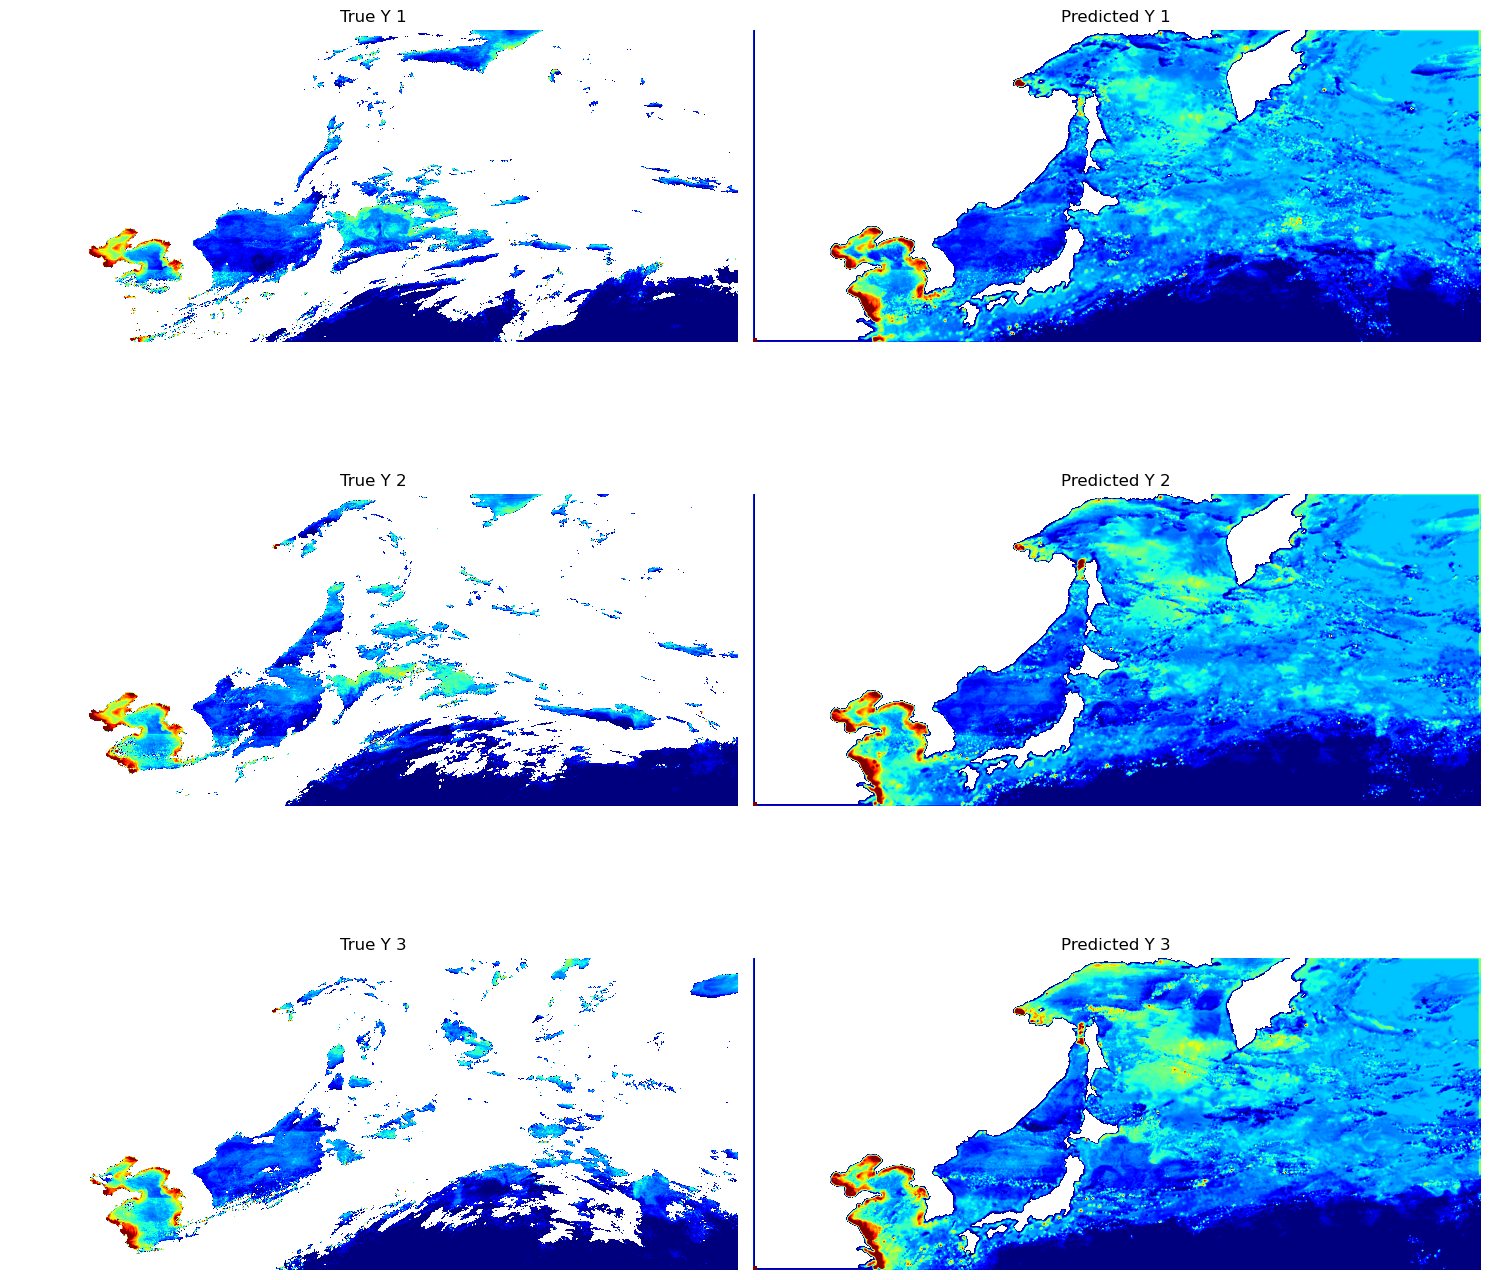

In [ ]:
def visualize_infer_results(num_samples=1):
    """
    可视化前 num_samples 张推理结果（显示真实值和预测值）。
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(15, 5 * num_samples))
    # 保证 axes 为2维数组
    if num_samples == 1:
        axes = np.array([axes])
        
    for i in range(num_samples):
        ax1, ax2 = axes[i]
        
        # 显示真实值
        ax1.imshow(infer_ds['chlor_a'][i], cmap=cmap, norm=norm, origin='lower')
        ax1.set_title(f"True Y {i+1}")
        ax1.axis('off')
        
        # 显示预测值
        ax2.imshow(ypred[i, :, :, 0], cmap=cmap, norm=norm, origin='lower')
        ax2.set_title(f"Predicted Y {i+1}")
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

# 调用函数进行可视化
visualize_infer_results(num_samples=3)

转为xarray数据集

In [ ]:
# 从原始数据集中获取有效的时间坐标（滑动窗口预测结果，只保留没有边界填充的数据）
sample_times = infer_ds['time'].values[t : t + ypred_squeezed.shape[0]]

pred_ds = xr.Dataset(
    {
        "chlor_a_pred": (["time", "latitude", "longitude"], ypred_squeezed)
    },
    coords={
        "time": sample_times,
        "latitude": infer_ds['latitude'].values,
        "longitude": infer_ds['longitude'].values
    },
    attrs={"description": "Predicted chlor_a values"}
)


pred_ds

<xarray.Dataset>
Dimensions:       (time: 3173, latitude: 601, longitude: 1401)
Coordinates:
  * time          (time) datetime64[ns] 2015-07-05 2015-07-06 ... 2024-03-11
  * latitude      (latitude) float32 30.0 30.05 30.1 30.15 ... 59.9 59.95 60.0
  * longitude     (longitude) float32 110.0 110.1 110.1 ... 179.9 180.0 180.0
Data variables:
    chlor_a_pred  (time, latitude, longitude) float32 5.659e+05 ... 0.2538
Attributes:
    description:  Predicted chlor_a values

合并xarray

In [ ]:
# 合并原始数据集和预测数据集
ds_combined = xr.merge([infer_ds, pred_ds])

# 打印合并后的数据集
ds_combined

<xarray.Dataset>
Dimensions:           (latitude: 601, longitude: 1401, time: 3179)
Coordinates:
  * latitude          (latitude) float32 30.0 30.05 30.1 ... 59.9 59.95 60.0
  * longitude         (longitude) float32 110.0 110.1 110.1 ... 180.0 180.0
  * time              (time) datetime64[ns] 2015-07-02 2015-07-03 ... 2024-03-14
Data variables:
    chlor_a           (time, latitude, longitude) float32 -1.0 -1.0 ... -2.0
    chlor_a_filtered  (time, latitude, longitude) float32 -1.0 -1.0 ... -2.0
    chlor_a_pred      (time, latitude, longitude) float32 nan nan ... nan nan
Attributes: (12/13)
    title:                          Himawari-08 AHI equal latitude-longitude ...
    id:                             H08_20150702_0350_1D_ROC021_FLDK.02401_02...
    date_created:                   2023-05-21T12:06:42Z
    pixel_number:                   2401
    line_number:                    2401
    upper_left_latitude:            60.0
    ...                             ...
    grid_interval:                  0.05
    band_number:                    8
    algorithm version:              
    Ancillary meteorological data:  Unavailable
    Ancillary ozone data:           Unavailable
    BRDF correction:                on (Morel and Maritorena 2001)

海陆遮蔽

In [ ]:
def apply_land_mask(ds_pred, land_invalid_value=-1):
    """
    使用 regionmask 对 ds_pred 应用海陆掩蔽，将陆地标记为指定的无效值。
    
    参数：
      - ds_pred: 包含预测数据的 xarray.Dataset，应包含 "chlor_a_pred" 变量。
      - land_invalid_value: 用于标记陆地的值（默认 -1）
      
    返回：
      - 更新后的 ds_pred
    """
    import regionmask
    land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
    mask = land.mask(ds_pred.longitude, ds_pred.latitude)
    ds_pred["chlor_a_pred"] = xr.where(mask == 0, land_invalid_value, ds_pred["chlor_a_pred"])
    return ds_pred

ds_combined = apply_land_mask(ds_combined)

C:\Users\wangjh\AppData\Local\Temp\ipykernel_17468\3544506107.py:13: UserWarning: `land_50` of `natural_earth_v4_1_0` and `natural_earth_v5_0_0` does not quite extend to 90°S - it's recommended to use `natural_earth_v5_1_2` instead. See https://github.com/regionmask/regionmask/issues/487
  land = regionmask.defined_regions.natural_earth_v5_0_0.land_50


可视化检查

In [ ]:
import os

def visualize_chlor_a_last(ds_combined, ds_pred, ds_all, cmap='jet', norm=norm, num_samples_to_visualize=1, save_fig=False, output_dir=None):
    """
    使用 Cartopy 将真实数据和经海陆掩蔽处理后的预测数据进行可视化。
    
    参数：
      - ds_combined: 包含真实 chlor_a 数据的 xarray.Dataset
      - ds_pred: 已经应用海陆掩蔽的预测 xarray.Dataset
      - ds_all: 原始数据集，用于获取经纬度范围
      - cmap: colormap，默认 'jet'
      - norm: 归一化映射，默认使用之前定义的 norm
      - num_samples_to_visualize: 要可视化的时间点个数（默认 1）
      - save_fig: 是否保存图片（默认 False）
      - output_dir: 保存图片的目录（如果 save_fig 为 True，则必须指定）
    """
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs

    times_to_plot = ds_pred["time"].values[:num_samples_to_visualize]
    extent = [
        float(ds_all["longitude"].min()),
        float(ds_all["longitude"].max()),
        float(ds_all["latitude"].min()),
        float(ds_all["latitude"].max())
    ]
    
    fig, axes = plt.subplots(num_samples_to_visualize, 2, figsize=(15, 5 * num_samples_to_visualize),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    # 如果只有一个样本，确保 axes 是二维数组
    if num_samples_to_visualize == 1:
        axes = [axes]
        
    for idx, t_stamp in enumerate(times_to_plot):
        ax1, ax2 = axes[idx]
        
        true_data = ds_combined["chlor_a"].sel(time=t_stamp).values
        pred_data = ds_pred["chlor_a_pred"].sel(time=t_stamp).values

        im1 = ax1.imshow(true_data, cmap=cmap, norm=norm, extent=extent, origin="lower")
        ax1.set_title(f"True chlor_a at {str(t_stamp)}")
        ax1.set_xlabel("Longitude (°E)")
        ax1.set_ylabel("Latitude (°N)")
        ax1.coastlines()
        fig.colorbar(im1, ax=ax1, orientation="vertical")

        im2 = ax2.imshow(pred_data, cmap=cmap, norm=norm, extent=extent, origin="lower")
        ax2.set_title(f"Predicted chlor_a at {str(t_stamp)}")
        ax2.set_xlabel("Longitude (°E)")
        ax2.set_ylabel("Latitude (°N)")
        ax2.coastlines()
        fig.colorbar(im2, ax=ax2, orientation="vertical")

    plt.tight_layout()
    
    if save_fig:
        if output_dir is None:
            raise ValueError("output_dir must be specified if save_fig is True")
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        fig_path = os.path.join(output_dir, f"chlor_a_visualization_{num_samples_to_visualize}.png")
        plt.savefig(fig_path)
        plt.close(fig)
        print(f"Figure saved to {fig_path}")
    else:
        plt.show()

# 调用函数进行可视化并保存图片
visualize_chlor_a_last(ds_combined, ds_combined, infer_ds, cmap='jet', norm=norm, num_samples_to_visualize=30, save_fig=True, output_dir=output_dir)

d:\miniconda3\envs\tensorflow2.10_py39\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Figure saved to output/Unet_t3_chlor_a_output\chlor_a_visualization_30.png


保存预测得到的nc文件

In [ ]:
# 保存为 netCDF 文件，文件名包含模型名称和 t 的数值
output_nc_file = f"{output_dir}/{model_name}_t{t}_{var_x_list_name}_predictions.nc"
infer_ds.to_netcdf(output_nc_file)
print(f"Predicted results saved to {output_nc_file}")

Predicted results saved to output/Unet_t3_chlor_a_output/Unet_t3_chlor_a_predictions.nc


In [ ]:
# 保存为 netCDF 文件，文件名包含模型名称和 t 的数值
output_nc_file = f"{output_dir}/{model_name}_t{t}_{var_x_list_name}_ds_combined.nc"
ds_combined.to_netcdf(output_nc_file)
print(f"Predicted results saved to {output_nc_file}")

Predicted results saved to output/Unet_t3_chlor_a_output/Unet_t3_chlor_a_ds_combined.nc


# 模型测试

In [ ]:
from datetime import datetime
test_file_list = val_file_list
# 记录测试结果的字典
test_results = {}

# 遮蔽模式列表
mask_modes = ["random", "block"] 

# 遮蔽比例列表
ratios = np.arange(0.1, 1.1, 0.1)

for mode in mask_modes:
    for ratio in ratios:
        # 为当前遮蔽模式和比例创建测试数据生成器
        test_generator = tf.data.Dataset.from_generator(
            lambda: dynamic_generator(test_file_list, t, augment_flag=True, mode=mode, corruption_ratio=ratio, shuffle=False),
            output_signature=output_signature
        ).batch(batch_size, drop_remainder=False)
        
        # 计算测试步数
        test_steps = int(np.ceil(len(test_file_list) / batch_size))
        
        # 评估当前配置下的模型性能
        test_metrics = model.evaluate(
            test_generator,
            steps=test_steps,
            verbose=0
        )
        
        # 保存结果
        result_key = f"{mode}_{ratio:.1f}"
        test_results[result_key] = {
            'mse': test_metrics[1],
            'mae': test_metrics[2],
            'rmse': test_metrics[3],
            'r2': test_metrics[4]
        }
        
        # 打印当前配置的评估结果
        print(f"\nMask Mode: {mode}, Ratio: {ratio:.1f} | MSE: {test_metrics[1]:.4f} | MAE: {test_metrics[2]:.4f} | RMSE: {test_metrics[3]:.4f} | R2: {test_metrics[4]:.4f}")
        # 获取当前时间戳
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        # 将评估结果追加保存到输出文件夹中的 test.log 文件
        output_file = os.path.join(output_dir, "test.log")
        with open(output_file, "a") as f:
            f.write(f"{timestamp} | Mask Mode: {mode}, Ratio: {ratio:.1f} | "
                f"MSE: {test_metrics[1]:.4f} | MAE: {test_metrics[2]:.4f} | "
                f"RMSE: {test_metrics[3]:.4f} | R2: {test_metrics[4]:.4f}\n")
        print(f"Test results appended to {output_file}")



Mask Mode: random, Ratio: 0.1 | MSE: 0.0194 | MAE: 0.0309 | RMSE: 0.1266 | R2: 0.9905
Test results appended to output/Unet_t3_chlor_a_output\test.log

Mask Mode: random, Ratio: 0.2 | MSE: 0.0353 | MAE: 0.0394 | RMSE: 0.1728 | R2: 0.9819
Test results appended to output/Unet_t3_chlor_a_output\test.log

Mask Mode: random, Ratio: 0.3 | MSE: 0.0530 | MAE: 0.0463 | RMSE: 0.2127 | R2: 0.9729
Test results appended to output/Unet_t3_chlor_a_output\test.log

Mask Mode: random, Ratio: 0.4 | MSE: 0.0720 | MAE: 0.0534 | RMSE: 0.2487 | R2: 0.9637
Test results appended to output/Unet_t3_chlor_a_output\test.log

Mask Mode: random, Ratio: 0.5 | MSE: 0.0963 | MAE: 0.0616 | RMSE: 0.2878 | R2: 0.9518
Test results appended to output/Unet_t3_chlor_a_output\test.log

Mask Mode: random, Ratio: 0.6 | MSE: 0.1271 | MAE: 0.0717 | RMSE: 0.3304 | R2: 0.9371
Test results appended to output/Unet_t3_chlor_a_output\test.log

Mask Mode: random, Ratio: 0.7 | MSE: 0.1696 | MAE: 0.0841 | RMSE: 0.3813 | R2: 0.9184
Test re

# 代码保存及关闭

保存当前的notebook

In [ ]:
import os
import shutil

current_nb_path =  os.path.abspath('main.ipynb')

dest_path = os.path.join(output_dir, f"{model_name}_t{t}_{var_x_list_name}.ipynb")
shutil.copy(str(current_nb_path), dest_path)
print(f"Notebook 已保存到: {dest_path}")

Notebook 已保存到: output/Unet_t3_chlor_a_output\Unet_t3_chlor_a.ipynb


关闭notebook，释放系统资源

In [ ]:
import tensorflow as tf
import sys

tf.keras.backend.clear_session()

exit()

: 